In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/ForeignGifts_edu.csv")

df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [5]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

The different classes of gift types are contracts, monetary gifts and real estate.

In [5]:
country_total_don = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)

country_total_don

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

Qatar gives the most money in total.

In [4]:
country_count_don = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False)

country_count_don

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
               ... 
ERITREA           1
ARMENIA           1
ANTIGUA           1
PALAU             1
ROMANIA           1
Name: Foreign Gift Amount, Length: 155, dtype: int64

England initiates the most gifts by count.

In [13]:
country_avg_don = df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False)

country_avg_don

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Name: Foreign Gift Amount, Length: 155, dtype: float64

Bermuda gives the largest gifts on average.

In [22]:
uni_total_don = df.groupby('Institution Name')['Foreign Gift Amount'].sum().reset_index().sort_values(by='Foreign Gift Amount', ascending=False)

uni_total_don.head(20)

,Institution Name,Foreign Gift Amount
45,Carnegie Mellon University,1477922504
62,Cornell University,1289937761
87,Harvard University,954803610
114,Massachusetts Institute of Technology,859071692
315,Yale University,613441311
185,Texas A&M University,521455050
99,Johns Hopkins University,502409595
143,Northwestern University,402316221
81,Georgetown University,379950511
209,University of Chicago (The),364544338


Carnegie Mellon receives the most money in total.

In [7]:
uni_count_don = df.groupby('Institution Name')['Foreign Gift Amount'].count().sort_values(ascending=False)

uni_count_don.head(20)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
University of Michigan - Ann Arbor              715
Stanford University                             668
Cornell University                              653
University of Pennsylvania                      625
Massachusetts Institute of Technology           582
Yale University                                 550
Harvard University                              453
University of Colorado Denver                   436
University of Chicago (The)                     401
Arizona State University                        400
University of California, Berkeley              394
Colorado State University                       379
University of Texas at Austin                   377
Texas A&M University                           

UCLA receives the highest number of gifts.

In [29]:
uni_total_don_bar = px.bar(uni_total_don.head(20), x='Foreign Gift Amount', y='Institution Name', title='Top 20 Universities by Total Foreign Gift Amount')

uni_total_don_bar.show()

In [37]:
mean_total_don = uni_total_don['Foreign Gift Amount'].mean()

mean_total_don

np.float64(52202878.974842764)

In [38]:
median_total_don = uni_total_don['Foreign Gift Amount'].median()

median_total_don

np.float64(6486791.5)

In [42]:
fig = px.histogram(uni_total_don, x='Institution Name', y='Foreign Gift Amount', title='Histogram of Foreign Gift Amounts by Institution', nbins=50)
fig.show()

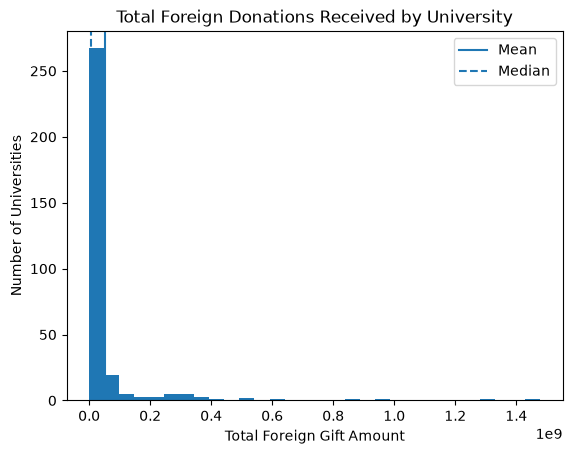

In [46]:
import matplotlib.pyplot as plt

plt.hist(uni_total_don['Foreign Gift Amount'], bins=30)

plt.axvline(mean_total_don, linestyle='-', label='Mean')
plt.axvline(median_total_don, linestyle='--', label='Median')
plt.xlabel('Total Foreign Gift Amount')
plt.ylabel('Number of Universities')
plt.title('Total Foreign Donations Received by University')
plt.legend()

plt.show()

In [34]:
import plotly.graph_objects as go

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()